In [ ]:
# Check what you uploaded
import os
from datetime import datetime
from google.colab import files
import zipfile

In [ ]:
# 1. Upload your ZIP file
print("Please select your dataset ZIP file:")
uploaded = files.upload()

# 2. Extract the ZIP
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print(f"✅ Extracted {filename} to /content/")

# 3. Verify extraction
!ls /content/

Please select your dataset ZIP file:


Saving Archive.zip to Archive.zip
✅ Extracted Archive.zip to /content/
Archive.zip  data  __MACOSX  model_config.yml  sample_data


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.9 MB/s eta 0:00:00


# Train yolo

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.0 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/model_config.yml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640,

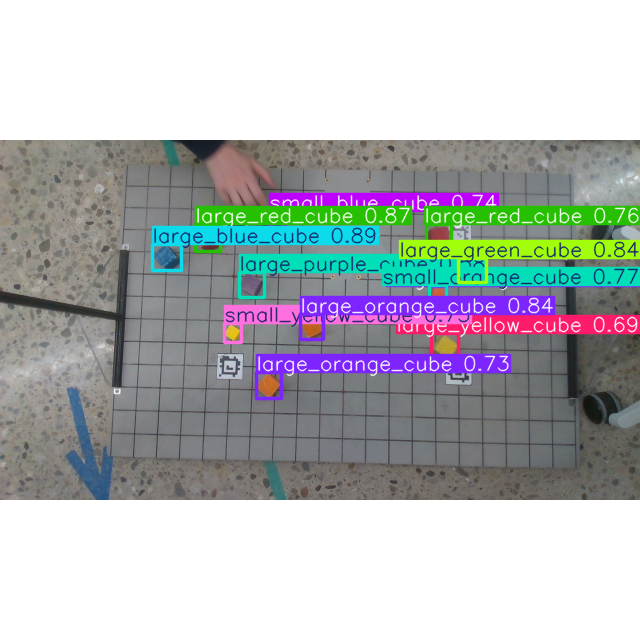

Saved to: /content/cubes_model_20260418_024718.pt


In [ ]:
from ultralytics import YOLO
import torch
from datetime import datetime
import os


DATA_DIR = "/content/data"
IMAGE_ID = 45

# Load a model
pretrained_model = "yolov8s.pt"
model = YOLO(pretrained_model)

# Train the model
train_results = model.train(
    workers=2,
     batch=8,
    data="/content/model_config.yml",
    epochs=40,  # number of training epochs
    imgsz=640,  # training image size
    device=0,
    iou=0.6,                    # IoU threshold for NMS (lower for dense clusters)
    conf=0.25,                  # confidence threshold
    augment=True,               # use data augmentation
    overlap_mask=True,
)

# Evaluate model performance on the validation set
metrics = model.val(
    data="/content/model_config.yml",  # Update path
    imgsz=640,
    batch=8,
    device="cuda",
    conf=0.25,
    iou=0.5,
    verbose=True,
    plots=True,  # Generate plots
    save_json=True,  # Save results to JSON
    save_hybrid=True,  # Save hybrid labels
)

print("\n=== Detection Metrics ===")
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# Per-class metrics
if hasattr(metrics, 'box') and hasattr(metrics.box, 'ap_class_index'):
    print("\n=== Per-Class Performance ===")
    for i, class_id in enumerate(metrics.box.ap_class_index):
        class_name = model.names[class_id]
        ap50 = metrics.box.ap50[i]
        ap = metrics.box.ap[i]
        print(f"{class_name}: mAP@0.5={ap50:.4f}, mAP@0.5:0.95={ap:.4f}")


# Perform object detection on an image
results = model(f"{DATA_DIR}/images/val/frame_{str(IMAGE_ID)}.png")
results[0].show()


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_path = f"/content/cubes_model_{timestamp}.pt"

model.save(export_path)
print(f"Saved to: {export_path}")


In [ ]:
from ultralytics import YOLO
import time
import cv2
import numpy as np

model = YOLO(f"/content/runs/detect/train/weights/best.pt")
image_path = "/content/data/images/val/frame_40.png"

# Load image
image = cv2.imread(image_path)

# Simulate video stream (process same image multiple times)
n_frames = 100
fps_history = []

print(f"🎬 Simulating video stream - {n_frames} frames...")

for i in range(n_frames):
    start = time.time()
    results = model(image)
    frame_time = (time.time() - start) * 1000
    fps_history.append(1000 / frame_time)

    if (i + 1) % 20 == 0:
        avg_fps = np.mean(fps_history[-20:])
        print(f"   Frame {i+1}: {avg_fps:.1f} FPS")

avg_fps = np.mean(fps_history)
print(f"\n📊 Overall: {avg_fps:.1f} FPS ({1000/avg_fps:.2f} ms per frame)")

🎬 Simulating video stream - 100 frames...
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 1 large_orange_cube, 1 large_yellow_cube, 79.8ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 384x640 (no detections), 100.3ms
Speed: 2.8ms preprocess, 90.0ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)
WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 1 large_orange_cube, 1 large_yellow_cube, 13.6ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 384x640 (no detections), 18.6ms
Speed: 3.8ms preprocess, 16.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
WARNING ⚠️ 'source' is missing. Using 'source=/usr/

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,134,872 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3081.5±734.5 MB/s, size: 364.0 KB)
val: Scanning /content/data/labels/val.cache... 13 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13/13 2.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.9s
                   all         13        138      0.866      0.953      0.961      0.614
     small_orange_cube         13         15      0.949      0.867      0.943      0.575
     small_yellow_cube          8          8      0.818          1      0.926      0.551
       small_blue_cube          6          6      0.845          1      0.972        0.5
     small_purple_cube          8          8      0.989       0.75      0.967      0.595
        large_red_cube         13         24      0.888  

array([    0.61397,     0.61397,     0.61397,     0.57498,     0.61397,     0.55132,     0.61397,     0.61397,     0.61397,     0.50011,     0.61397,     0.59465,     0.61397,     0.69561,     0.61397,     0.67642,     0.61397,     0.60841,     0.61397,     0.61808,     0.61397,     0.64124,     0.61397,     0.67886])


image 1/1 /content/img.png: 640x640 2 large_yellow_cubes, 2 large_green_cubes, 16.2ms
Speed: 2.9ms preprocess, 16.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


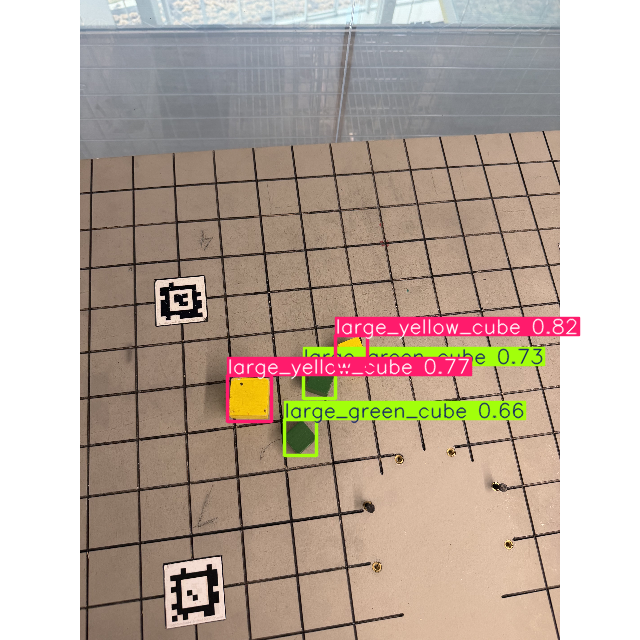

In [ ]:
from google.colab.patches import cv2_imshow
image_path = "/content/img.png"
image = cv2.imread(image_path)
results = model(image_path)
cv2_imshow(results[0].plot())

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([17., 17., 19., 19.], device='cuda:0')
conf: tensor([0.8161, 0.7699, 0.7257, 0.6648], device='cuda:0')
data: tensor([[335.0264, 335.5522, 367.3962, 369.8822,   0.8161,  17.0000],
        [227.2326, 375.8138, 271.2285, 421.2207,   0.7699,  17.0000],
        [303.4656, 365.4962, 335.3643, 398.0219,   0.7257,  19.0000],
        [284.1210, 419.1071, 316.4819, 455.4497,   0.6648,  19.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([4, 6])
xywh: tensor([[351.2113, 352.7172,  32.3699,  34.3300],
        [249.2305, 398.5173,  43.9958,  45.4069],
        [319.4149, 381.7590,  31.8987,  32.5258],
        [300.3015, 437.2784,  32.3610,  36.3426]], device='cuda:0')
xywhn: tensor([[0.5488, 0.5511, 0.0506, 0.0536],
        [0.3894, 0.6227, 0.0687, 0.0709],
        [0.4991, 0.5965, 0.0498, 0.0508],
        [0.4692, 0.6832, 0.0506, 0.0568]], device='cuda:0')
xyxy: tensor([[335.0264, 335.552

In [ ]:
print(dir(results[0]))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_keys', 'boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save', 'save_crop', 'save_dir', 'save_txt', 'show', 'speed', 'summary', 'to', 'to_csv', 'to_df', 'to_json', 'update', 'verbose']


In [ ]:
print(dir(results[0].boxes))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'cls', 'conf', 'cpu', 'cuda', 'data', 'id', 'is_track', 'numpy', 'orig_shape', 'shape', 'to', 'xywh', 'xywhn', 'xyxy', 'xyxyn']


In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([17., 17., 19., 19.], device='cuda:0')
conf: tensor([0.8161, 0.7699, 0.7257, 0.6648], device='cuda:0')
data: tensor([[335.0264, 335.5522, 367.3962, 369.8822,   0.8161,  17.0000],
        [227.2326, 375.8138, 271.2285, 421.2207,   0.7699,  17.0000],
        [303.4656, 365.4962, 335.3643, 398.0219,   0.7257,  19.0000],
        [284.1210, 419.1071, 316.4819, 455.4497,   0.6648,  19.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (640, 640)
shape: torch.Size([4, 6])
xywh: tensor([[351.2113, 352.7172,  32.3699,  34.3300],
        [249.2305, 398.5173,  43.9958,  45.4069],
        [319.4149, 381.7590,  31.8987,  32.5258],
        [300.3015, 437.2784,  32.3610,  36.3426]], device='cuda:0')
xywhn: tensor([[0.5488, 0.5511, 0.0506, 0.0536],
        [0.3894, 0.6227, 0.0687, 0.0709],
        [0.4991, 0.5965, 0.0498, 0.0508],
        [0.4692, 0.6832, 0.0506, 0.0568]], device='cuda:0')
xyxy: tensor([[335.0264, 335.552

In [ ]:
# The names dictionary maps class IDs (0, 1, 2) to names ('person', 'car', 'dog')
class_names = results[0].names

# Loop through every detected box in the image
for box in results[0].boxes:
    # 1. Get the class ID and Name
    class_id = int(box.cls[0].item())
    class_name = class_names[class_id]

    # 2. Get the confidence score
    confidence = round(box.conf[0].item(), 2)

    # 3. Get the bounding box coordinates
    # xyxy format: [x_min, y_min, x_max, y_max]
    bbox = box.xyxy[0].tolist()

    # Print the result
    print(f"Detected: {class_name} (Confidence: {confidence}) | Box: {bbox}")

Detected: large_yellow_cube (Confidence: 0.82) | Box: [335.0263671875, 335.5521545410156, 367.396240234375, 369.8821716308594]
Detected: large_yellow_cube (Confidence: 0.77) | Box: [227.23260498046875, 375.8138427734375, 271.22845458984375, 421.220703125]
Detected: large_green_cube (Confidence: 0.73) | Box: [303.465576171875, 365.49615478515625, 335.3642578125, 398.02191162109375]
Detected: large_green_cube (Confidence: 0.66) | Box: [284.1209716796875, 419.10711669921875, 316.48193359375, 455.44970703125]


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
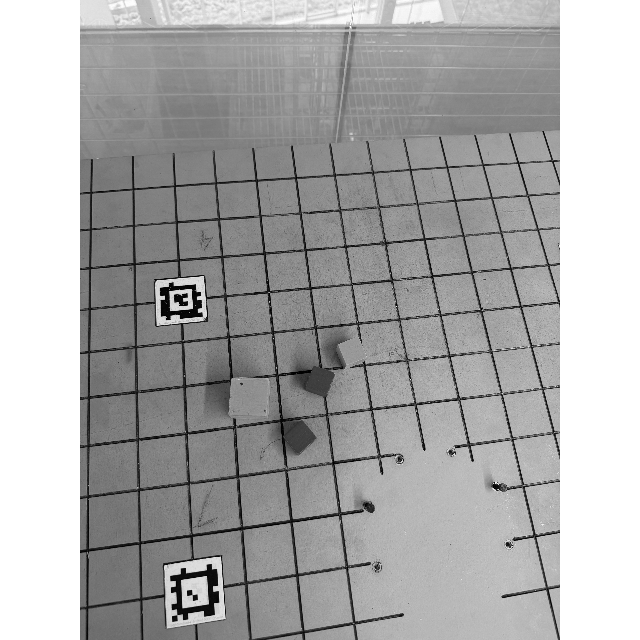

In [ ]:

image_path = "/content/img.png"
image = cv2.imread(image_path)

def letterbox(image, new_size=640):
    h, w = image.shape[:2]

    scale = min(new_size / w, new_size / h)
    new_w, new_h = int(w * scale), int(h * scale)

    resized = cv2.resize(image, (new_w, new_h))

    # create padded image
    canvas = 255 * np.ones((new_size, new_size, 3), dtype=np.uint8)

    # center the image
    x_offset = (new_size - new_w) // 2
    y_offset = (new_size - new_h) // 2

    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return canvas

newImage = letterbox(image)
gray = cv2.cvtColor(newImage, cv2.COLOR_RGB2GRAY)
gray

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
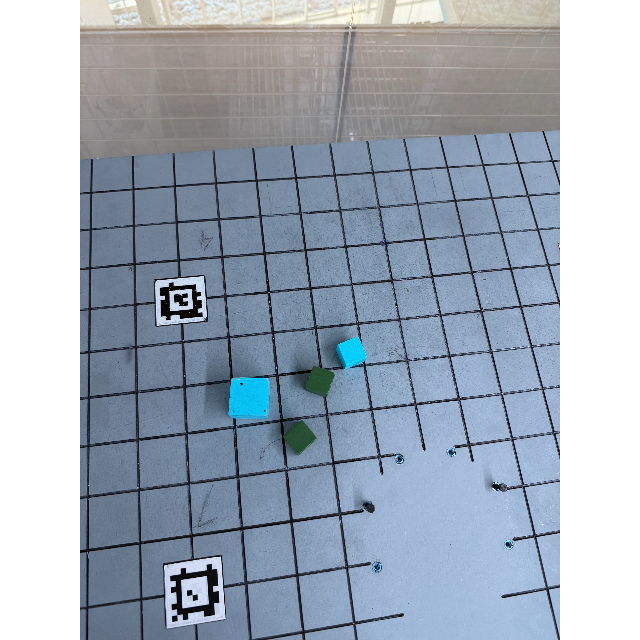

In [ ]:
image